#HW3 Image Classifications

In [1]:
import numpy as np
import os
import pandas as pd
import copy

##DataHandeling

In [2]:
!pip install -q kagglehub pandas

In [3]:
import kagglehub
import shutil

src_path = kagglehub.dataset_download("zalando-research/fashionmnist")
dst_path = "/content/fashionmnist"

shutil.copytree(src_path, dst_path, dirs_exist_ok=True)

print("Saved to:", dst_path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Saved to: /content/fashionmnist


In [4]:
df = pd.read_csv("/content/fashionmnist/fashion-mnist_train.csv")

In [5]:
import pandas as pd
import numpy as np
from PIL import Image
import os

df = pd.read_csv("/content/fashionmnist/fashion-mnist_train.csv")

os.makedirs("digit_images", exist_ok=True)

for idx, row in df.iterrows():
    label = row['label']
    pixels = row[1:].values
    pixels = pixels.reshape(28,28).astype(np.uint8)
    img = Image.fromarray(pixels, mode='L')
    img.save(f"digit_images/{idx}_{label}.png")
    if idx < 5:
        img.show()


/tmp/ipython-input-2124442445.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L')  # 'L' = grayscale
/tmp/ipython-input-2124442445.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L')  # 'L' = grayscale
/tmp/ipython-input-2124442445.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L')  # 'L' = grayscale
/tmp/ipython-input-2124442445.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L')  # 'L' = grayscale
/tmp/ipython-input-2124442445.py:21: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L')  # 'L' = grayscale
/tmp/ipython-input-212444

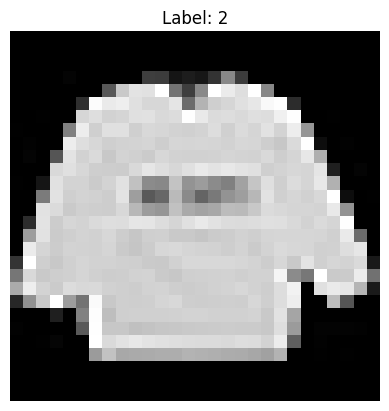

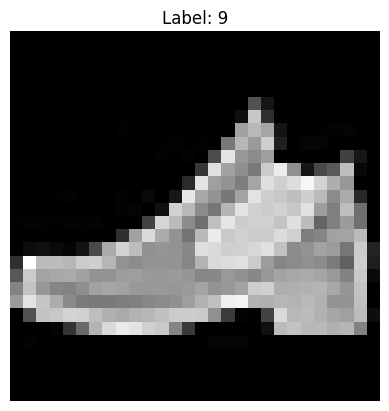

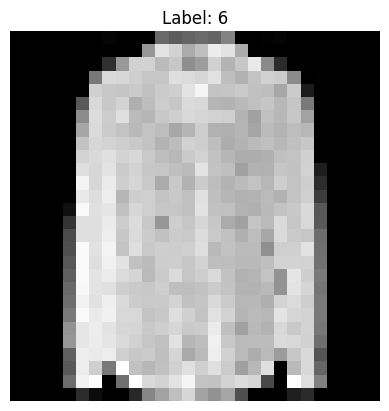

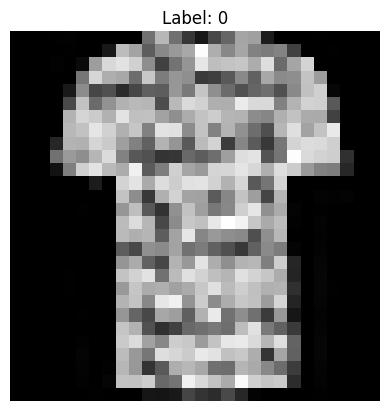

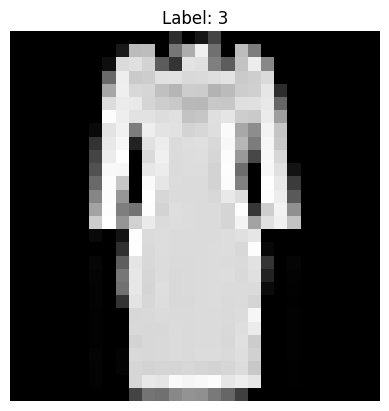

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

N = 5
for idx in range(N):
    row = df.iloc[idx]
    label = row['label']
    pixels = row[1:].values.reshape(28,28)

    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()


##Prossess Data

In [7]:
def load_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((32, 32))
    img = np.array(img, dtype=np.float32) / 255.0
    return img.flatten()

import pandas as pd
def row_to_flat_image(row):
    pixels = row[1:].values.reshape(28, 28)
    pixels = pixels.astype(np.float32) / 255.0  # normalize data from 0-1
    return pixels.flatten() #shape 784

X = np.stack(df.apply(row_to_flat_image, axis=1))


labels = df['label'].values
classes = np.unique(labels)
class_to_idx = {c: i for i, c in enumerate(classes)}
y = np.eye(len(classes))[[class_to_idx[l] for l in labels]]

print("X shape:", X.shape)  # (num_samples, 784)
print("y shape:", y.shape)  # (num_samples, 10)


X shape: (60000, 784)
y shape: (60000, 10)


##Nerual Network From Scratch


###Functions

In [8]:
class MatrixFunctions:
  def __init__(self):
    MatrixFunctions="Active"

  def sigmoid(self, x):
    return 1 / (1 + np.exp(-x))

  def softmax(self, x):
    x = x - np.max(x)
    exp = np.exp(x)
    return exp / np.sum(exp)

  def matrixRelu(self, input_nodes, wieghts, bias):
    output_nodes = np.matmul(wieghts, input_nodes)
    output_nodes+=bias
    output_nodes[output_nodes<0]=0
    return output_nodes

  def matrixSigmoid(self, input_nodes, wieghts, bias):
    output_nodes = np.matmul(wieghts, input_nodes)
    output_nodes+=bias
    output_nodes = self.sigmoid(output_nodes)
    return output_nodes

  def createDefualtWieghts(self, input_nodes, output_nodes):
    return np.random.rand(output_nodes, input_nodes) * np.sqrt(2 / input_nodes)

  def createDefualtBias(self, output_nodes):
    return np.zeros(output_nodes)


In [9]:
class NetworkContector:
  def __init__(self):
    self.wieghts = []
    self.bias = []
    self.MAX_W = 1.5

  def backPropagation(self, inputs, gradient, recieved, learning_rate, is_output=False):
    if is_output:
      delta = recieved - gradient
    else:
      delta = gradient * (recieved > 0).astype(float)
    old_weights = self.weights.copy()
    d_weights = np.outer(delta, inputs)
    self.weights -= learning_rate * d_weights
    self.bias -= learning_rate * delta
    next_gradient = np.dot(old_weights.T, delta)
    return next_gradient

In [10]:
class NueralNetwork:
  def __init__(self, matrix_shape):
    self.matrix_shape = matrix_shape
    self.matrix = []
    self.matrix_functs = MatrixFunctions()
    self.learing_Rate = 0.01
    self.configureMatrix()
    self.output="Sigmoid"

  def configureMatrix(self):
    self.matrix = []
    for i in range(len(self.matrix_shape)-1):
        net_connect = NetworkContector()
        net_connect.weights = self.matrix_functs.createDefualtWieghts(self.matrix_shape[i], self.matrix_shape[i+1])
        net_connect.bias = self.matrix_functs.createDefualtBias(self.matrix_shape[i+1])
        self.matrix.append(net_connect)
    return self.matrix

  def backPropagation(self, node_values, expected):
    gradient = expected
    for i in reversed(range(len(self.matrix))):
      recieved = node_values[1+i]
      inputs = node_values[i]
      is_output = (i == len(self.matrix) - 1)
      gradient = self.matrix[i].backPropagation(inputs, gradient, recieved, self.learing_Rate, is_output)

  def runNetwork(self, input_nodes):
      nodeValues = [np.array(input_nodes)]
      for i in range(len(self.matrix)):
          z = np.matmul(self.matrix[i].weights, nodeValues[i]) + self.matrix[i].bias
          if i == len(self.matrix) - 1:
              a = self.matrix_functs.softmax(z)
          else:
              a = np.maximum(0, z)
          nodeValues.append(a)
      return nodeValues



In [11]:
class Epoch:
  def __init__(self, matrix):
    self.matrix=matrix
    self.matrix.configureMatrix()

  def train(self, x_train, y_train, x_test, y_test):
    total_loss = 0
    t_val_loss = 0
    correct = 0
    for i in range(len(x_train)):
      nodeValues = self.matrix.runNetwork(copy.deepcopy(x_train[i]))
      pred = copy.deepcopy(nodeValues[-1])
      self.matrix.backPropagation(nodeValues, copy.deepcopy(y_train[i]))
      error = pred - y_train[i]
      loss = -np.sum(y_train[i] * np.log(pred + 1e-9))
      total_loss += loss

    for i in range(len(x_test)):
      nodeValues = self.matrix.runNetwork(copy.deepcopy(x_test[i]))
      pred = nodeValues[-1]
      error = pred - y_test[i]
      val_loss = -np.sum(y_test[i] * np.log(pred + 1e-9))
      t_val_loss += val_loss
      correct += int(np.argmax(pred)==np.argmax(y_test[i]))

    return total_loss/len(y_train), t_val_loss/len(y_test), correct/len(x_test)

###Run Network

In [13]:
nueralNetwork = NueralNetwork([784, 64, 64, 10])
Train = Epoch(nueralNetwork)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
for i in range(10):
  loss=0
  batch_size = 1000
  indices = np.random.choice(len(X_train), batch_size, replace=False)

  X_batch = X_train[indices]
  y_batch = y_train[indices]
  train_loss, val_loss, acc = Train.train(X_batch, y_batch, X_test, y_test)
  print(f"Epoch {i+1}: Train Loss: {train_loss:.5f} [] Val Loss: {val_loss:.5f} [] Accuracy: {(acc*100):.2f}%")

Epoch 1: Train Loss: 2.16331 [] Val Loss: 1.87050 [] Accuracy: 30.77%
Epoch 2: Train Loss: 1.55213 [] Val Loss: 1.35431 [] Accuracy: 51.58%
Epoch 3: Train Loss: 1.16060 [] Val Loss: 1.09765 [] Accuracy: 56.45%
Epoch 4: Train Loss: 0.99269 [] Val Loss: 0.89212 [] Accuracy: 64.65%
Epoch 5: Train Loss: 0.89822 [] Val Loss: 0.77918 [] Accuracy: 70.50%
Epoch 6: Train Loss: 0.77980 [] Val Loss: 0.77741 [] Accuracy: 70.05%
Epoch 7: Train Loss: 0.73779 [] Val Loss: 0.68948 [] Accuracy: 72.67%
Epoch 8: Train Loss: 0.67844 [] Val Loss: 0.66835 [] Accuracy: 76.38%
Epoch 9: Train Loss: 0.70947 [] Val Loss: 0.63234 [] Accuracy: 77.10%
Epoch 10: Train Loss: 0.68707 [] Val Loss: 0.62608 [] Accuracy: 77.22%


I used minibatching as the dataset was to big this allowed me to train effeciently. Mini batching each epoch takes less time while still learning same features.

##Neural Network using tenserflow

https://www.tensorflow.org/guide/intro_to_modules

Tensorflow is a great resourse in making complex neral networks.  It allows you to build networks via layers. With that you can then tweak settings on how training is done. To make this dual hidden layer network, all we need is to state a input layer and its size, the two hidden layers thier size + activation relu, and finaly our output layer witch will use softmax. Back propication and learning rate will all be handled by tenserflow.

In [26]:
import tensorflow as tf
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(784, )),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


For part 5 inputs are defualt set to normilized as how they normaly are for image data

In [28]:
model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_1.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2929 - val_accuracy: 0.8675 - val_loss: 0.3763
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8939 - loss: 0.2824 - val_accuracy: 0.8634 - val_loss: 0.3740
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8964 - loss: 0.2814 - val_accuracy: 0.8694 - val_loss: 0.3629
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8992 - loss: 0.2734 - val_accuracy: 0.8724 - val_loss: 0.3663
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8996 - loss: 0.2708 - val_accuracy: 0.8718 - val_loss: 0.3557


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step


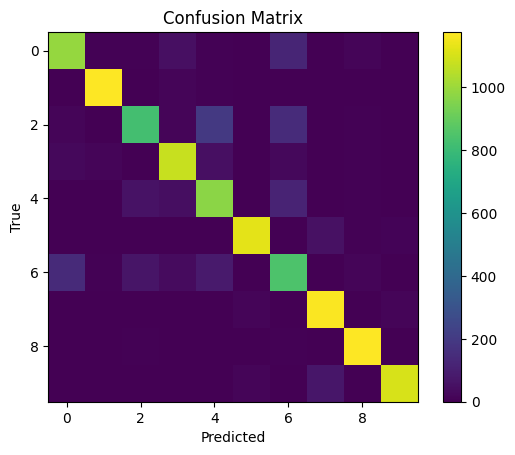

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred = model_1.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

if len(y_test.shape) > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()
#Note dataset labels were literly 1 2 3(Also datapart of this problem is handeled at top.)

I used the hyper paremeters that I normaly use. Adams defualts to 0.001 witch is a good rate for most problems. Adams defualt settings are genrely great especialy for clasification. I chose 5 epochs instead of 10 as thats when the networks learning slowed down. I decided to not use regulization because the test scores did not decrease that much when training was run for much longer. Likley due to the large dataset used.